In this collab the final best pipeline is inclded for preprocessing, feature extraction, evaluation and performance measurements

##### Connect to drive



In [ ]:
!pip install mne

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

import os, re
from glob import glob
import numpy as np
import pandas as pd
from typing import Sequence


Mounted at /content/drive


### Main Pipeline

####Data reading

Make sure to change the data path for the data

In [ ]:
# set electrode names and order

ELECTRODES = [
    'Fp1','AF7','AF3','F1','F3','F5','F7','FT7','FC5','FC3','FC1',
    'C1','C3','C5','T7','TP7','CP5','CP3','CP1','P1','P3','P5','P7','P9',
    'PO7','PO3','O1','Oz','POz','Pz','CPz','Fpz',
    'Fp2','AF8','AF4','AFz','Fz','F2','F4','F6','F8','FT8','FC6','FC4',
    'FC2','FCz','Cz','C2','C4','C6','T8','TP8','CP6','CP4','CP2',
    'P2','P4','P6','P8','P10','PO8','PO4','O2'
]
num_electrods = len(ELECTRODES)

####

DATA_ROOT = "/content/drive/MyDrive/PRIVATE_DATASET" ### change this for local data path ###

####

BOTH_DIR = os.path.join(DATA_ROOT, "both")
NONE_DIR = os.path.join(DATA_ROOT, "none")

fname_re = re.compile(r"pilot(\d+)_evnt(\d+)_session(\d+)_.*\.csv$", re.IGNORECASE) # file name parsing


# actual data read in
def parse_meta(path: str) -> dict:
    base = os.path.basename(path)
    m = fname_re.match(base)
    return {
        "pilot": int(m.group(1)) if m else None,
        "event": int(m.group(2)) if m else None,
        "session": int(m.group(3)) if m else None,
        "path": path
    }

def load_eeg(path: str) -> np.ndarray:
    df = pd.read_csv(path, header=None)
    if df.shape[0] != num_electrods:
        raise ValueError(f"{path}: expected {num_electrods} rows (electrodes), got {df.shape[0]}")
    if df.shape[1] == 0:
        raise ValueError(f"{path}: has 0 columns (no time samples)")
    df.index = ELECTRODES
    return df.to_numpy(dtype=np.float32)  # (63, T)

# Collect files
both_files = sorted(glob(os.path.join(BOTH_DIR, "*.csv")))
none_files = sorted(glob(os.path.join(NONE_DIR, "*.csv")))

print("both:", len(both_files), "none:", len(none_files))
if len(both_files) == 0 and len(none_files) == 0:
    raise FileNotFoundError("No CSV files found. Check DATA_ROOT/BOTH_DIR/NONE_DIR paths.")

all_paths = both_files + none_files

# creat y vector 1=both, 0=none
y = np.array([1]*len(both_files) + [0]*len(none_files), dtype=np.int64)

#create data in correct format
meta = [parse_meta(p) for p in all_paths]
Xs = [load_eeg(p) for p in all_paths]

X = np.stack(Xs, axis=0)  #(N, 63, T)

subjects = np.array([m["pilot"] for m in meta], dtype=np.int64)

#sanity dimension printing
print(subjects.shape)
print("Unique subjects:", np.unique(subjects))

print("X:", X.shape, X.dtype, "| y:", y.shape, y.dtype)
print("Example meta:", meta[0])

both: 640 none: 641
(1281,)
Unique subjects: [ 1  2  3  4  5  6  7  8  9 10 11 12 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33]
X: (1281, 63, 359) float32 | y: (1281,) int64
Example meta: {'pilot': 10, 'event': 10, 'session': 1, 'path': '/content/drive/MyDrive/BioSignal_group04/Real/both/pilot10_evnt10_session1_noisy.csv'}


####Preprocessing

In [ ]:
# Main preprocessing loop

from scipy import signal

import numpy as np
from scipy import signal

fs = 265

# create FIR filter method for band pass
def bandpass_iir_filtfilt(X, fs, low=1.0, high=35.0, order=4):
    sos = signal.butter(order, [low, high], btype="bandpass", fs=fs, output="sos")
    X_f = signal.sosfiltfilt(sos, X, axis=-1)
    return X_f.astype(np.float32)
#apply badn pass filter
X_filtered = bandpass_iir_filtfilt(X, fs=fs, low=1.0, high=35.0, order=4)
#apply baseline removal
X_baseline_removed = X_filtered - X_filtered.mean(axis=-1, keepdims=True)
#apply detrending
X_detrended = signal.detrend(X_baseline_removed, axis=-1, type="linear").astype(np.float32)

#resuting datasets
# X                    --> raw EEG
# X_filtered           --> bandpass filtered
# X_baseline_removed   --> filtered + mean removed
# X_detrended          --> final cleaned EEG


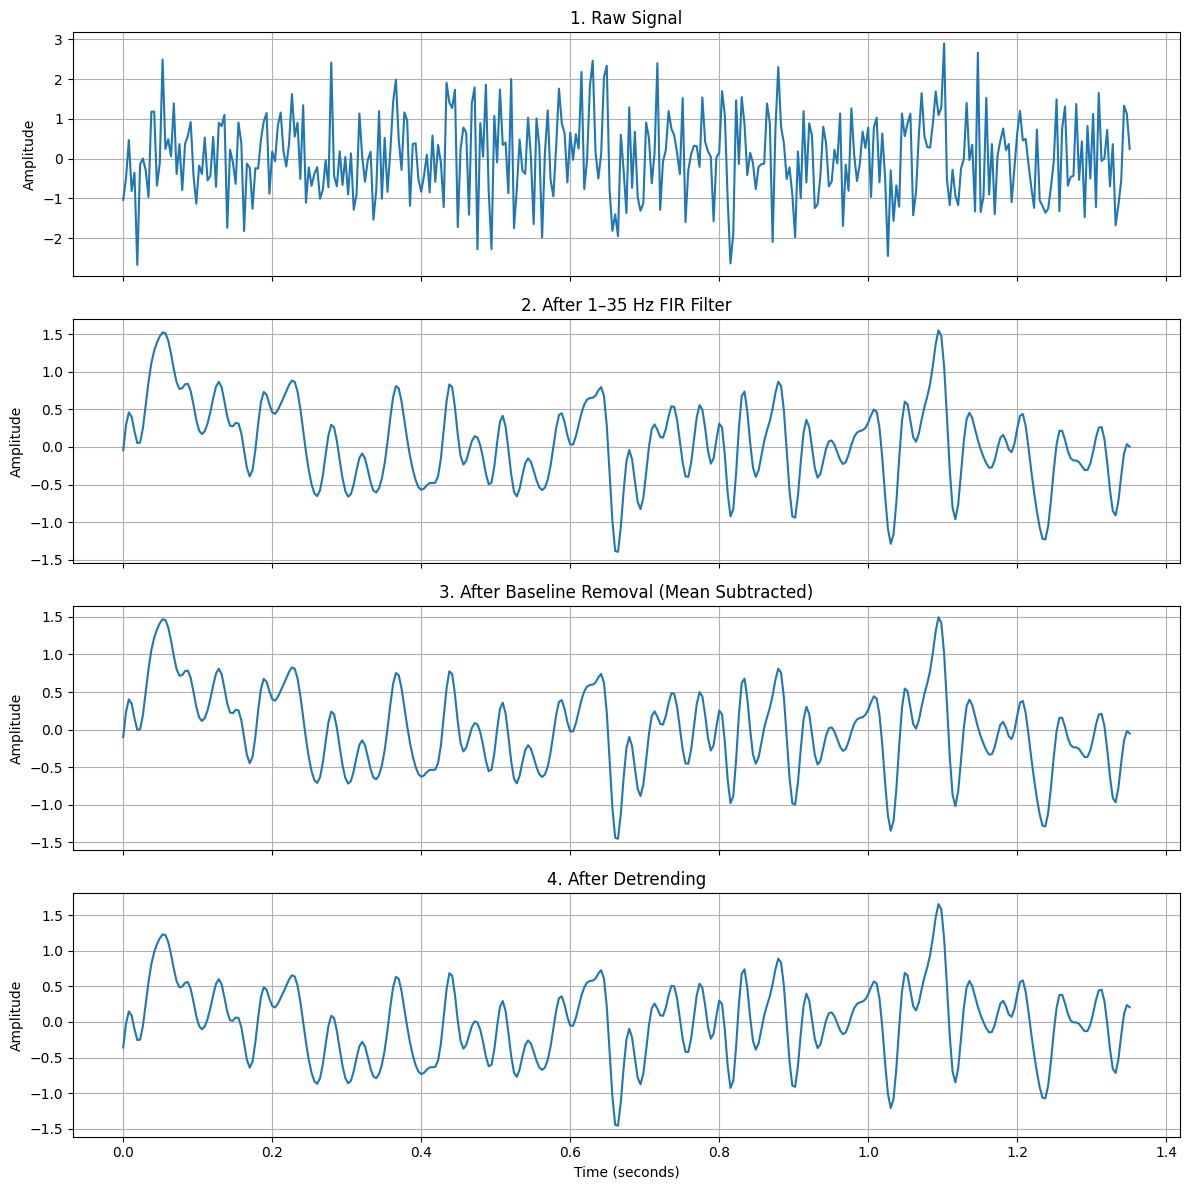


Metadata for displayed signal
-----------------------------
Electrode : Cz
Pilot     : 10
Session   : 1
Event     : 20
Label     : both
File path : /content/drive/MyDrive/BioSignal_group04/Real/both/pilot10_evnt20_session1_noisy.csv


In [ ]:

import matplotlib.pyplot as plt
# plot signal and preprocessed signal stepwise for sanity check and understanding

s = 256                # sampling frequency
trial_idx = 11          # which trial
electrode_name = "Cz"  # which electrode

electrode_idx = ELECTRODES.index(electrode_name)
t = np.arange(X.shape[2]) / fs

# extract specific signal from dataset
example_raw_sig = X[trial_idx, electrode_idx, :]
example_filtered_sig = X_filtered[trial_idx, electrode_idx, :]
example_baseline_removed_sig = X_baseline_removed[trial_idx, electrode_idx, :]
example_detrended_sig = X_detrended[trial_idx, electrode_idx, :]


#plot:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(t, example_raw_sig)
axes[0].set_title("1. Raw Signal")

axes[1].plot(t, example_filtered_sig)
axes[1].set_title("2. After 1–35 Hz FIR Filter")

axes[2].plot(t, example_baseline_removed_sig)
axes[2].set_title("3. After Baseline Removal (Mean Subtracted)")

axes[3].plot(t, example_detrended_sig)
axes[3].set_title("4. After Detrending")

for ax in axes:
    ax.set_ylabel("Amplitude")
    ax.grid(True)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

#additionally print metadata of printed signal
label_map = {1: "both", 0: "none"}
m = meta[trial_idx]

print("\nMetadata for displayed signal")
print("-----------------------------")
print(f"Electrode : {electrode_name}")
print(f"Pilot     : {m.get('pilot')}")
print(f"Session   : {m.get('session')}")
print(f"Event     : {m.get('event')}")
print(f"Label     : {label_map.get(y[trial_idx], y[trial_idx])}")
print(f"File path : {m.get('path')}")

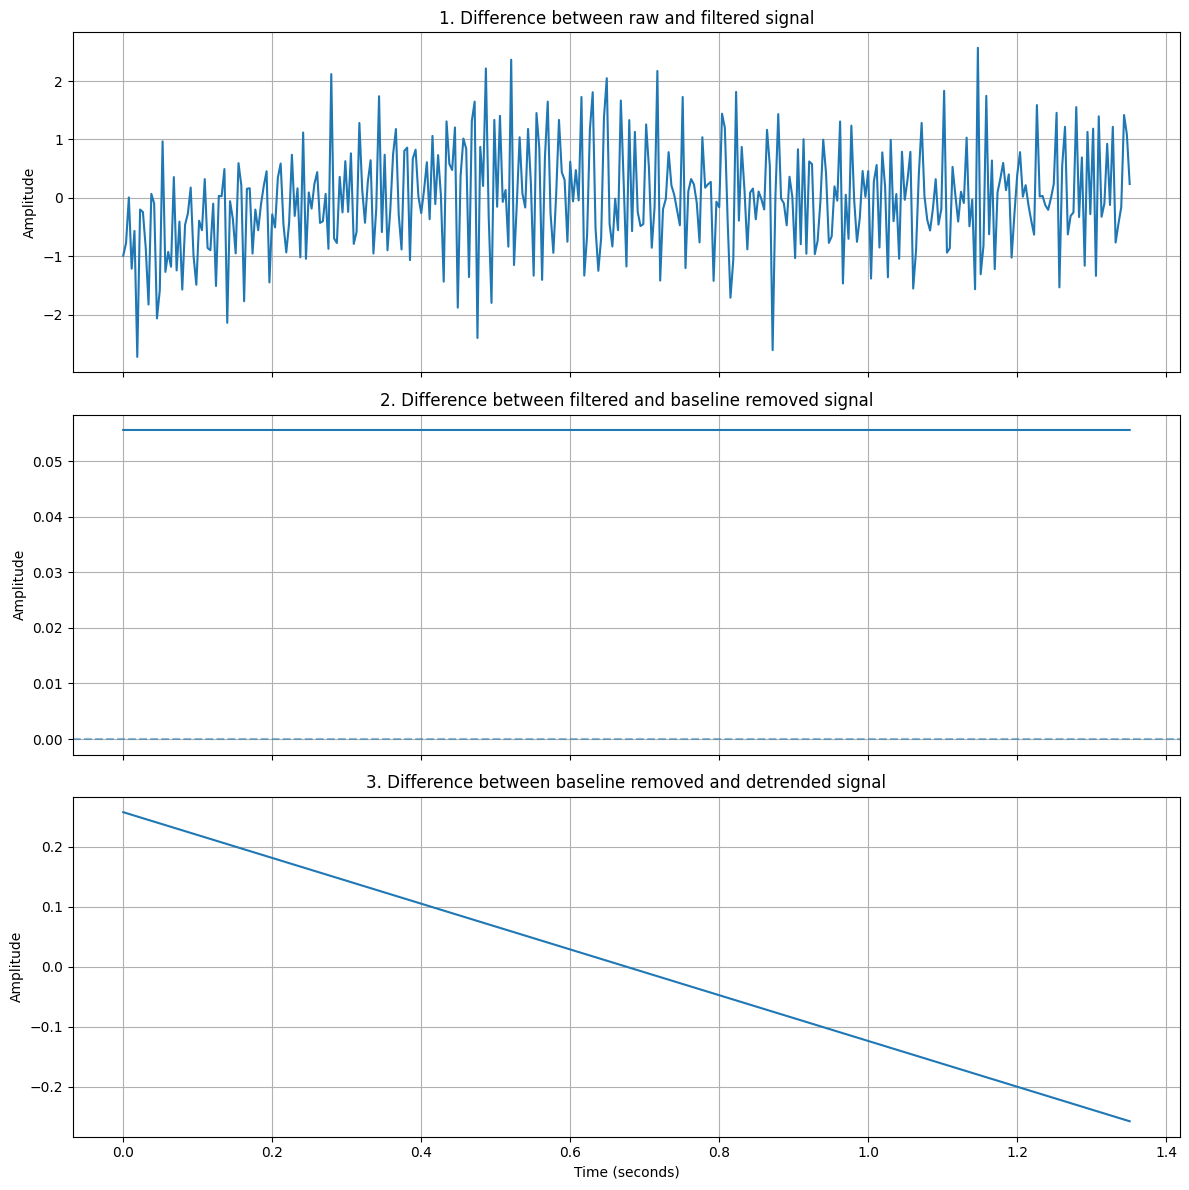

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# show differences of signal before/between and after pre-processing tp see effect on signal

# signal differences
diff_raw_filtered_sig = example_raw_sig - example_filtered_sig
diff_filtered_baselineRem_sig = example_filtered_sig - example_baseline_removed_sig
diff_baselineRem_detrended_sig = example_baseline_removed_sig - example_detrended_sig

#plot
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].plot(t, diff_raw_filtered_sig)
axes[0].set_title("1. Difference between raw and filtered signal")

axes[1].plot(t, diff_filtered_baselineRem_sig)
axes[1].axhline(0, linestyle='--', alpha=0.5)
axes[1].set_title("2. Difference between filtered and baseline removed signal")

axes[2].plot(t, diff_baselineRem_detrended_sig)
axes[2].set_title("3. Difference between baseline removed and detrended signal")

for ax in axes:
    ax.set_ylabel("Amplitude")
    ax.grid(True)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()


#### Features finding and analysis

In [ ]:
# Averaging procedure

X_both = X_detrended[y == 1]
X_none = X_detrended[y == 0]

avg_both_all = np.mean(X_both, axis=0) # Shape (63, T)
avg_none_all = np.mean(X_none, axis=0) # (63, T)

print("Averaging complete.")
print("Shape of average matrix:", avg_both_all.shape)

Averaging complete.
Shape of average matrix: (63, 359)


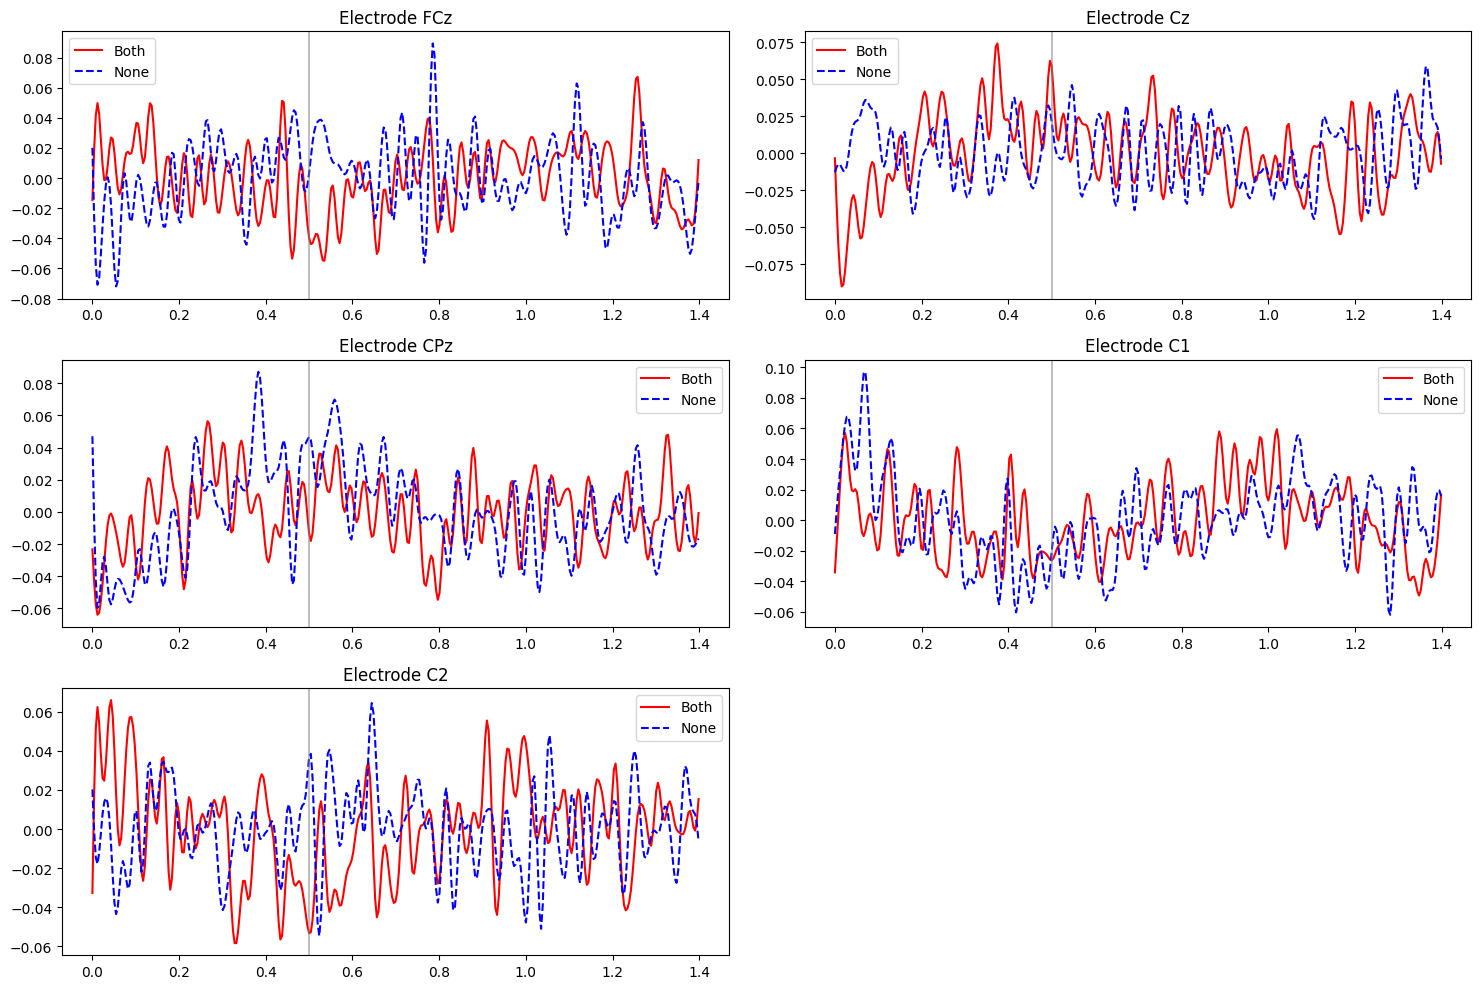

In [ ]:
# groups of interest for foot movement
central_electrodes = ['FCz', 'Cz', 'CPz', 'C1', 'C2']

t = np.arange(X_detrended.shape[2]) / 256 # Time axis

plt.figure(figsize=(15, 10))

for i, el in enumerate(central_electrodes):
    idx = ELECTRODES.index(el)
    plt.subplot(3, 2, i+1)
    plt.plot(t, avg_both_all[idx], label='Both', color='red')
    plt.plot(t, avg_none_all[idx], label='None', color='blue', linestyle='--')
    plt.title(f"Electrode {el}")
    plt.axvline(x=0.5, color='gray', alpha=0.5)
    plt.legend()

plt.tight_layout()
plt.show()

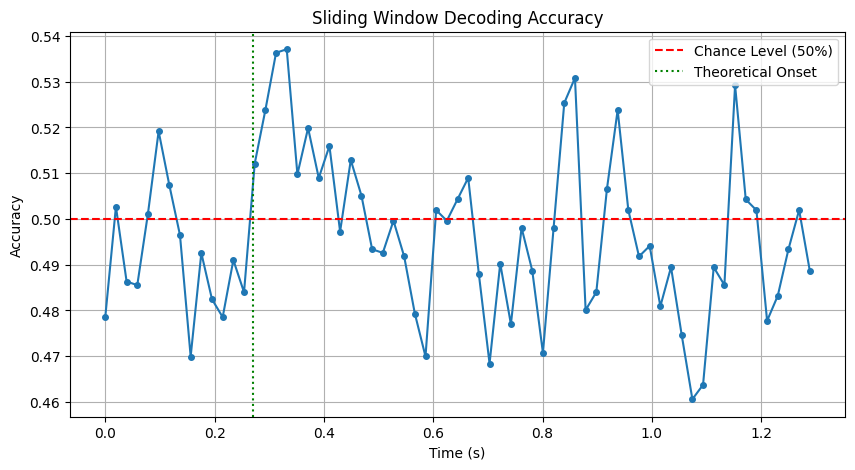

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Sliding window decoding analysis to find the ERPs
def sliding_window_decoding(X, y, window_size_ms=100, step_ms=20, fs=256.0):
    win_samples = int((window_size_ms / 1000) * fs)
    step_samples = int((step_ms / 1000) * fs)
    total_samples = X.shape[-1]

    times = []
    accuracies = []

    for start in range(0, total_samples - win_samples, step_samples):
        end = start + win_samples

        X_win = np.var(X[:, :, start:end], axis=-1)


        clf = Pipeline([('scaler', StandardScaler()), ('lda', LinearDiscriminantAnalysis())])
        scores = cross_val_score(clf, X_win, y, cv=5)

        times.append(start / fs)
        accuracies.append(np.mean(scores))

    #plot
    plt.figure(figsize=(10, 5))
    plt.plot(times, accuracies, marker='o', markersize=4)
    plt.axhline(0.5, color='red', linestyle='--', label='Chance Level (50%)')
    plt.axvline(0.27, color='green', linestyle=':', label='Theoretical Onset')
    plt.title("Sliding Window Decoding Accuracy")
    plt.xlabel("Time (s)")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

sliding_window_decoding(X_detrended, y)

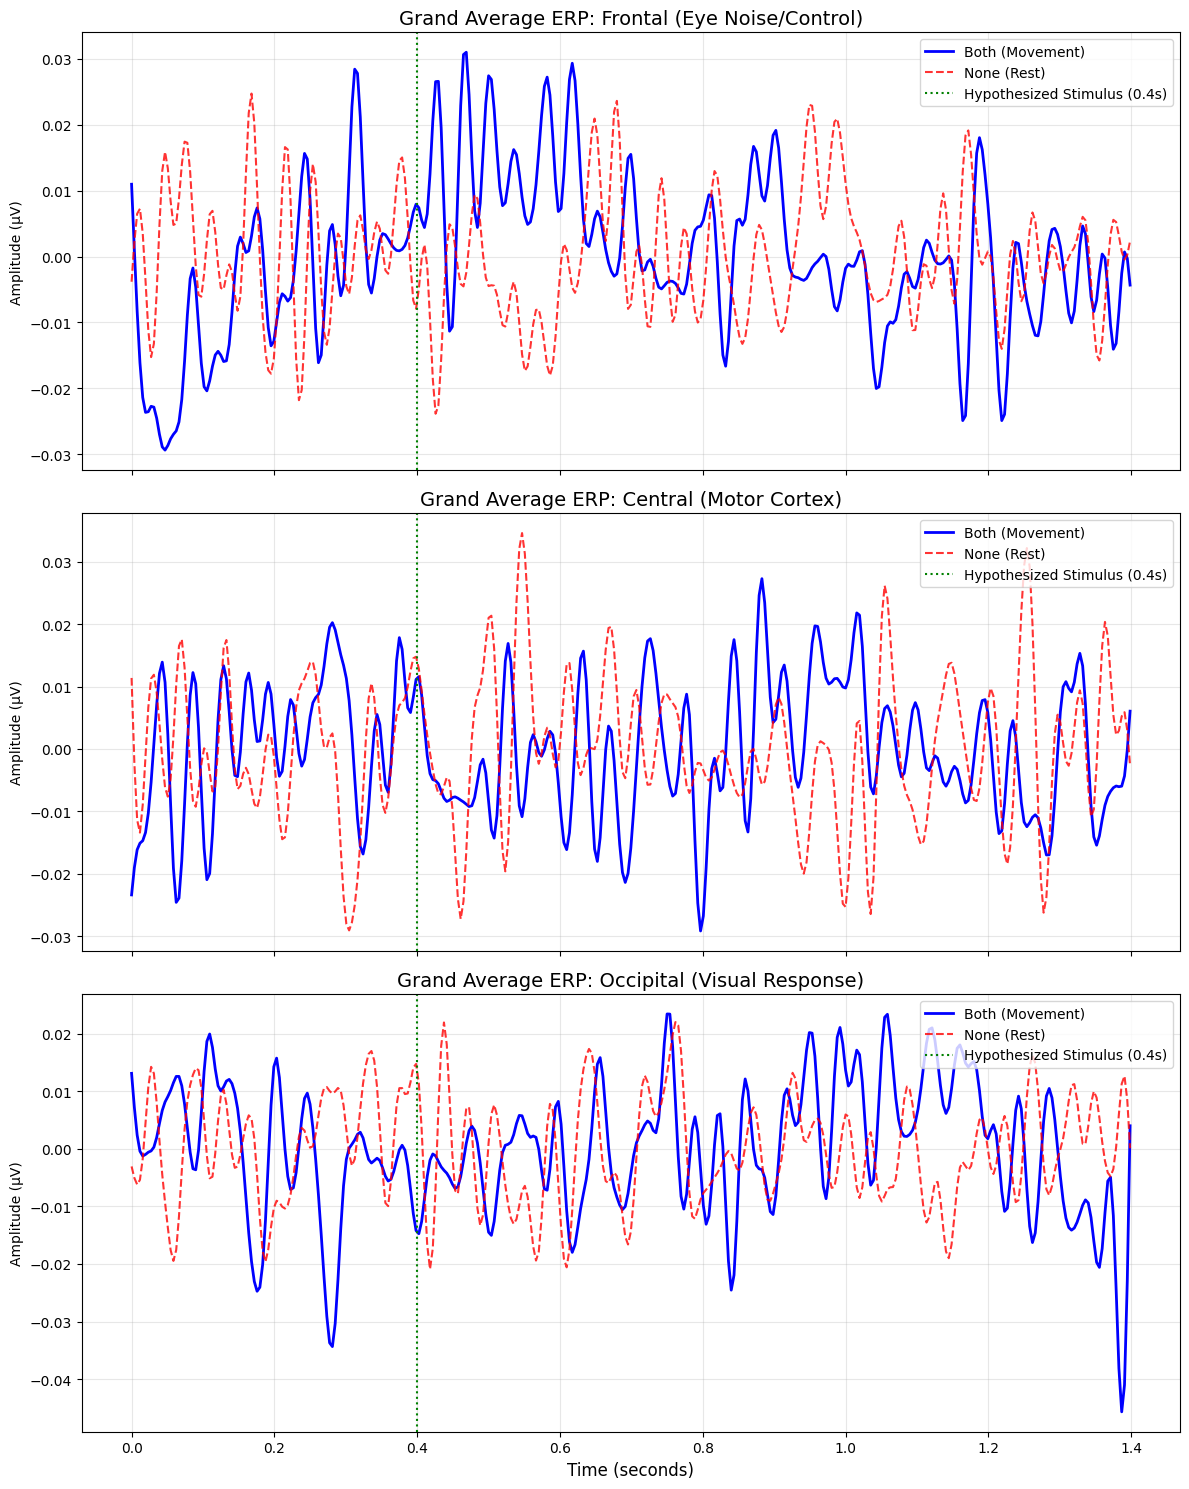

In [ ]:
# Setting areas of interest to find
regions = {
    "Frontal (Eye Noise/Control)": ["Fp1", "Fp2", "AFz", "Fz"],
    "Central (Motor Cortex)": ["Cz", "CPz", "C1", "C2"],
    "Occipital (Visual Response)": ["Oz", "POz", "O1", "O2"]
}

ga_both = np.mean(X_detrended[y == 1], axis=0)
ga_none = np.mean(X_detrended[y == 0], axis=0)

#plotting
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

for i, (region_name, ch_list) in enumerate(regions.items()):
    # Find electrode indices that belong in each area
    indices = [ELECTRODES.index(ch) for ch in ch_list if ch in ELECTRODES]

    both_region = np.mean(ga_both[indices, :], axis=0)
    none_region = np.mean(ga_none[indices, :], axis=0)

    axes[i].plot(t, both_region, label="Both (Movement)", color='blue', linewidth=2)
    axes[i].plot(t, none_region, label="None (Rest)", color='red', linestyle='--', alpha=0.8)


    axes[i].axvline(0.4, color='green', linestyle=':', label='Hypothesized Stimulus (0.4s)')

    axes[i].set_title(f"Grand Average ERP: {region_name}", fontsize=14)
    axes[i].set_ylabel("Amplitude (μV)")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel("Time (seconds)", fontsize=12)
plt.tight_layout()
plt.show()

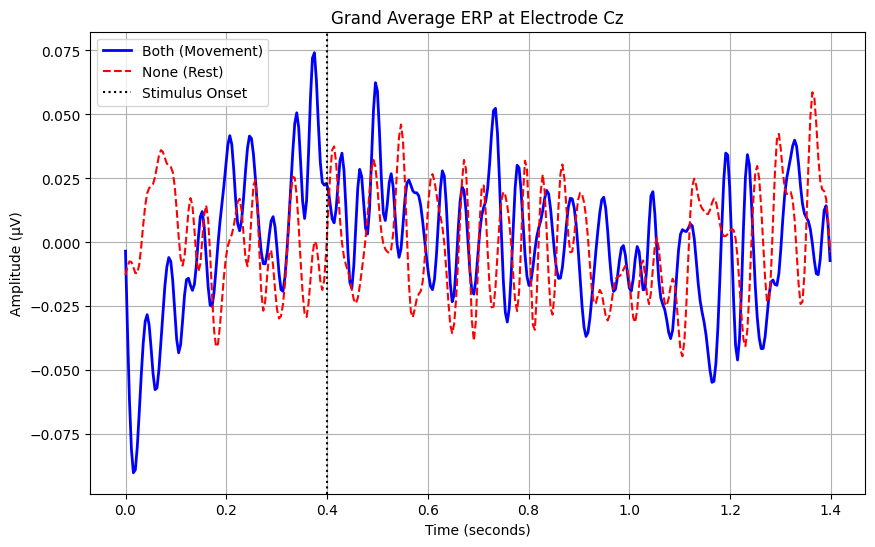

In [ ]:
# Visualization of grand average on electrode Cz in motor cortex
elec_idx = ELECTRODES.index("Cz")


plt.figure(figsize=(10, 6))
plt.plot(t, ga_both[elec_idx], label="Both (Movement)", color="blue", linewidth=2)
plt.plot(t, ga_none[elec_idx], label="None (Rest)", color="red", linestyle="--")

plt.axvline(0.4, color='black', linestyle=':', label='Stimulus Onset')
plt.title(f"Grand Average ERP at Electrode {ELECTRODES[elec_idx]}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (μV)")
plt.legend()
plt.grid(True)
plt.show()

#### Feature Extraction

##### without connectivity features

In [ ]:
# old FEATURE EXTRACTION pipeline

import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.stats import skew, kurtosis

def eeg_features_dataframe_old(
    X: np.ndarray,
    fs: float = 256.0,
    bands: dict | None = None,
    nperseg: int | None = None,
    noverlap: int | None = None,
    log_bandpower: bool = True,
    eps: float = 1e-12,
    ddof: int = 0,
) -> pd.DataFrame:
    """
    Invcludes:
    - Bandpowers & Ratios (Alpha/Beta)
    - Time-domain statistics (Variance, Skewness, Kurtosis)
    - Hjorth Parameters (Activity, Mobility, Complexity)
    - Spectral Entropy
    """
    if bands is None:
        bands = {
            "delta_1_4": (1.0, 4.0),
            "theta_4_8": (4.0, 8.0),
            "alpha_8_12": (8.0, 12.0),
            "beta_13_25": (13.0, 25.0),
            "gamma_25_35": (25.0, 35.0),
        }

    N, C, T = X.shape
    if nperseg is None: nperseg = min(256, T)
    if noverlap is None: noverlap = nperseg // 2

    # --- 1) PSD / Bandpower ---
    f, Pxx = welch(X, fs=fs, axis=-1, nperseg=nperseg, noverlap=noverlap, detrend="constant")
    dfreq = f[1] - f[0] if len(f) > 1 else 1.0
    band_names = list(bands.keys())
    band_feats = np.zeros((N, C, len(band_names)), dtype=np.float32)

    for bi, bname in enumerate(band_names):
        f_lo, f_hi = bands[bname]
        mask = (f >= f_lo) & (f <= f_hi)
        bp = Pxx[..., mask].sum(axis=-1) * dfreq
        if log_bandpower:
            bp = np.log(bp + eps)
        band_feats[..., bi] = bp

    # --- 2) Ratios (π.χ. Alpha/Beta) ---

    alpha_idx, beta_idx = 2, 3
    alpha_power = band_feats[..., alpha_idx]
    beta_power = band_feats[..., beta_idx]

    ab_ratio = alpha_power - beta_power if log_bandpower else alpha_power / (beta_power + eps)

    # --- 3) Time Domain Stats ---
    var_feat = np.var(X, axis=-1, ddof=ddof)
    skew_feat = skew(X, axis=-1)
    kurt_feat = kurtosis(X, axis=-1)

    # --- 4) Hjorth Parameters ---

    d1 = np.diff(X, axis=-1) # First Derivative
    d2 = np.diff(d1, axis=-1) # Second Derivative

    var_d1 = np.var(d1, axis=-1)
    var_d2 = np.var(d2, axis=-1)

    mobility = np.sqrt(var_d1 / (var_feat + eps))
    complexity = np.sqrt(var_d2 / (var_d1 + eps)) / (mobility + eps)

    # --- 5) Spectral Entropy ---
    psd_norm = Pxx / (np.sum(Pxx, axis=-1, keepdims=True) + eps)
    spec_entropy = -np.sum(psd_norm * np.log(psd_norm + eps), axis=-1)

    # --- Columns Altogether ---
    columns = []
    blocks = []

    # Bandpowers
    for bname in band_names:
        columns.extend([f"{bname}_{el}" for el in ELECTRODES])
    blocks.append(band_feats.reshape(N, C * len(band_names)))

    # Ratio
    columns.extend([f"alpha_beta_ratio_{el}" for el in ELECTRODES])
    blocks.append(ab_ratio)

    # Stats
    for name, data in zip(["var", "skew", "kurt", "entropy"], [var_feat, skew_feat, kurt_feat, spec_entropy]):
        columns.extend([f"{name}_{el}" for el in ELECTRODES])
        blocks.append(data)

    # Hjorth
    for name, data in zip(["mobility", "complexity"], [mobility, complexity]):
        columns.extend([f"{name}_{el}" for el in ELECTRODES])
        blocks.append(data)

    X_feat = np.concatenate(blocks, axis=1)
    return pd.DataFrame(X_feat, columns=columns)

##### with conectivity features

In [ ]:
# final feature extraction pipelin
import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.stats import skew, kurtosis

def extract_full_master_features(X, fs=256.0, electrodes=ELECTRODES):
    """
    Extracts ALL features (Matrix, Connectivity, ERP) from the FULL trial length.
    X shape: (Trials, Electrodes, Time)
    """
    N, C, T = X.shape
    eps = 1e-12
    times = np.arange(T) * (1000 / fs) # Time axis in ms

    bands = {
        "delta": (1.0, 4.0), "theta": (4.0, 8.0), "alpha": (8.0, 12.0),
        "beta": (13.0, 25.0), "gamma": (25.0, 35.0)
    }

    # --- 1. Frequency Domain & Complexity (PSD, Entropy, Hjorth) ---
    f, Pxx = welch(X, fs=fs, axis=-1, nperseg=min(T, 256))
    dfreq = f[1] - f[0]

    # Spectral Entropy
    psd_norm = Pxx / (np.sum(Pxx, axis=-1, keepdims=True) + eps)
    spec_entropy = -np.sum(psd_norm * np.log(psd_norm + eps), axis=-1)

    # Hjorth & Time Stats
    var_feat = np.var(X, axis=-1)
    d1 = np.diff(X, axis=-1)
    d2 = np.diff(d1, axis=-1)
    var_d1 = np.var(d1, axis=-1)
    var_d2 = np.var(d2, axis=-1)

    mobility = np.sqrt(var_d1 / (var_feat + eps))
    complexity = np.sqrt(var_d2 / (var_d1 + eps)) / (mobility + eps)
    skew_feat = skew(X, axis=-1)
    kurt_feat = kurtosis(X, axis=-1)

    # --- 2. Build the Data Blocks ---
    all_blocks = []
    all_names = []

    # Band Powers (Log)
    band_powers_log = {}
    for bname, (f_low, f_high) in bands.items():
        mask = (f >= f_low) & (f <= f_high)
        pw = np.log(Pxx[..., mask].sum(axis=-1) * dfreq + eps)
        band_powers_log[bname] = pw

        for el_idx, el in enumerate(electrodes):
            all_blocks.append(pw[:, el_idx])
            all_names.append(f"psd_log_{bname}_{el}")

    # Alpha/Beta Ratio & Complexity/Entropy
    for el_idx, el in enumerate(electrodes):
        # Ratio
        ab_ratio = band_powers_log["alpha"][:, el_idx] - band_powers_log["beta"][:, el_idx]
        all_blocks.append(ab_ratio)
        all_names.append(f"ratio_alpha_beta_{el}")

        # Hjorth, Entropy, Stats
        all_blocks.extend([
            var_feat[:, el_idx], skew_feat[:, el_idx], kurt_feat[:, el_idx],
            spec_entropy[:, el_idx], mobility[:, el_idx], complexity[:, el_idx]
        ])
        all_names.extend([
            f"var_{el}", f"skew_{el}", f"kurt_{el}",
            f"entropy_{el}", f"hjorth_mob_{el}", f"hjorth_comp_{el}"
        ])

        # --- 3. ERP Features (Peak & Latency) ---
        signal_trial = X[:, el_idx, :]
        peak_idx = np.argmax(np.abs(signal_trial), axis=-1)
        # Use advanced indexing to get peak values
        peak_vals = signal_trial[np.arange(N), peak_idx]
        latencies = times[peak_idx]

        all_blocks.extend([peak_vals, latencies])
        all_names.extend([f"erp_peak_{el}", f"erp_latency_{el}"])

    # --- 4. Connectivity (Pearson Correlation) ---
    all_conn = []
    conn_names = []
    upper_tri_indices = np.triu_indices(C, k=1)

    for i in range(N):
        corr_matrix = np.corrcoef(X[i, :, :])
        all_conn.append(corr_matrix[upper_tri_indices])

    if len(conn_names) == 0: # Create names once
        for row, col in zip(*upper_tri_indices):
            conn_names.append(f"corr_{electrodes[row]}_{electrodes[col]}")

    # --- Final Concatenation ---
    X_main = np.column_stack(all_blocks)
    X_conn = np.array(all_conn)

    df_main = pd.DataFrame(X_main, columns=all_names)
    df_conn = pd.DataFrame(X_conn, columns=conn_names)

    return pd.concat([df_main, df_conn], axis=1)

In [ ]:
fs = 256.0

idx_active_start = int(0.27 * fs)
idx_active_end = int(1 * fs)

#!!! can plug in old feature extraction pipeline for results without conectivity!!!
X_features_all = extract_full_master_features(X_detrended[:, :, int(idx_active_start):], fs=256.0)
#!!!

print(X_features_all.shape) # trials x electrods x 12 (featuree)
print(X_features_all.head(2))



(1281, 2835)
   psd_log_delta_Fp1  psd_log_delta_AF7  psd_log_delta_AF3  psd_log_delta_F1  \
0          -2.896867          -3.406314          -3.308351         -2.784801   
1          -5.258742          -2.563413          -3.759975         -3.063969   

   psd_log_delta_F3  psd_log_delta_F5  psd_log_delta_F7  psd_log_delta_FT7  \
0         -2.598622         -2.605544         -2.694193          -4.575543   
1         -2.058119         -2.771982         -2.022632          -3.059175   

   psd_log_delta_FC5  psd_log_delta_FC3  ...  corr_P8_P10  corr_P8_PO8  \
0          -2.081779          -2.114090  ...     0.032222    -0.035944   
1          -3.393401          -4.015601  ...     0.144825    -0.110105   

   corr_P8_PO4  corr_P8_O2  corr_P10_PO8  corr_P10_PO4  corr_P10_O2  \
0    -0.113193    0.020272     -0.012145      0.131649    -0.194009   
1     0.162637    0.150808      0.122860      0.199049     0.236265   

   corr_PO8_PO4  corr_PO8_O2  corr_PO4_O2  
0     -0.106621     0.124660  

In [ ]:
print(X_features_all.columns)

Index(['psd_log_delta_Fp1', 'psd_log_delta_AF7', 'psd_log_delta_AF3',
       'psd_log_delta_F1', 'psd_log_delta_F3', 'psd_log_delta_F5',
       'psd_log_delta_F7', 'psd_log_delta_FT7', 'psd_log_delta_FC5',
       'psd_log_delta_FC3',
       ...
       'corr_P8_P10', 'corr_P8_PO8', 'corr_P8_PO4', 'corr_P8_O2',
       'corr_P10_PO8', 'corr_P10_PO4', 'corr_P10_O2', 'corr_PO8_PO4',
       'corr_PO8_O2', 'corr_PO4_O2'],
      dtype='object', length=2835)


#### Feature Evaluation

In [ ]:
# cohens d as featuer based class seperation metric (used like correlatino or t-test pval)
def cohens_d(x1, x0):
    """
    Cohen's d for two independent samples
    """
    n1 = len(x1)
    n0 = len(x0)

    s1 = np.var(x1, ddof=1)
    s0 = np.var(x0, ddof=1)

    pooled_std = np.sqrt(
        ((n1 - 1) * s1 + (n0 - 1) * s0) / (n1 + n0 - 2)
    )

    return (np.mean(x1) - np.mean(x0)) / pooled_std


##### Find significant features based on t-test and correaltion (not used for final pipeline)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

# Keep feature names
feature_names = X_features_all.columns.to_numpy()

X = X_features_all.values
y = np.asarray(y)

X0 = X[y == 0]
X1 = X[y == 1]

results = []

for f, fname in enumerate(feature_names):
    feature = X[:, f]

    # Welch t-test
    t_stat, t_p = ttest_ind(X0[:, f], X1[:, f], equal_var=False)

    # Pearson correlation
    pearson_r, pearson_p = pearsonr(feature, y)

    # Spearman correlation
    spearman_r, spearman_p = spearmanr(feature, y)

    # Cohen's d
    d = cohens_d(X1[:, f], X0[:, f])

    results.append([
        fname,
        t_stat, t_p,
        pearson_r, pearson_p,
        spearman_r, spearman_p,
        d
    ])

cols = [
    "feature",
    "t_stat", "t_p",
    "pearson_r", "pearson_p",
    "spearman_r", "spearman_p",
    "cohens_d"
]

df = pd.DataFrame(results, columns=cols)

# Optional but useful
df["abs_cohens_d"] = df["cohens_d"].abs()
print(df.head(1))

             feature    t_stat       t_p  pearson_r  pearson_p  spearman_r  \
0  psd_log_delta_Fp1  1.089733  0.276036  -0.030457   0.276032   -0.033531   

   spearman_p  cohens_d  abs_cohens_d  
0    0.230414 -0.060895      0.060895  


In [ ]:
alpha = 0.05  # cut off for significance

# filter the features
significant = df[
    (df["t_p"] < alpha)
    & (df["pearson_p"] < alpha)
  & (df["spearman_p"] < alpha)
]

print("Significant features:", significant.shape[0])
print(significant.feature)

Significant features: 35
53            delta_1_4_CP4
69             theta_4_8_F7
81            theta_4_8_CP1
83             theta_4_8_P3
88            theta_4_8_PO3
142          alpha_8_12_CP5
146           alpha_8_12_P3
172           alpha_8_12_Cz
187          alpha_8_12_PO4
190          beta_13_25_AF7
227           beta_13_25_F4
267         gamma_25_35_TP7
296         gamma_25_35_FC2
311         gamma_25_35_P10
312         gamma_25_35_PO8
352     alpha_beta_ratio_F2
360    alpha_beta_ratio_FCz
368    alpha_beta_ratio_CP4
391                  var_C5
407                  var_Pz
411                 var_AF8
427                  var_C6
432                 var_CP2
496                 skew_P2
514                kurt_FC1
582             entropy_TP7
586              entropy_P1
601             entropy_AF4
606              entropy_F6
659             mobility_Pz
683            mobility_CP4
710          complexity_CP3
722           complexity_Pz
733           complexity_F8
746          complexity

##### Rank based on cohens

In [ ]:
# Cohen's significance calculation (cohen for eacht feature calculated above)

cohens_list = []

x1 = X_features_all[y == 1]
x0 = X_features_all[y == 0]

for col in X_features_all.columns:
    d = cohens_d(x1[col], x0[col])
    cohens_list.append({
        "feature": col,
        "abs_cohens_d": abs(d),
        "cohens_d": d
    })

df_new = pd.DataFrame(cohens_list)

# Chose top K features for testing
number_of_features_to_test = 500
top_k = min(number_of_features_to_test, len(df_new))
ranked = df_new.sort_values("abs_cohens_d", ascending=False)
top_features_df = ranked.head(top_k)


top_cohen_feature_names = top_features_df["feature"].values

print(f"Top 100 most important features: {top_cohen_feature_names[:100]}")

Top 100 most important features: ['corr_F8_FC6' 'corr_F5_PO4' 'hjorth_mob_Pz' 'entropy_TP7'
 'hjorth_comp_Pz' 'corr_C1_PO8' 'corr_P3_FC4' 'corr_AF3_AFz' 'corr_AFz_Fz'
 'corr_Pz_Fpz' 'corr_P5_Fp2' 'psd_log_gamma_C5' 'corr_TP7_FT8'
 'corr_Fp1_P4' 'corr_FC3_P5' 'corr_Fp1_FC5' 'corr_T7_P10'
 'erp_latency_AF8' 'corr_FC2_C2' 'psd_log_theta_O2' 'corr_F2_CP6'
 'corr_CP5_F6' 'corr_C3_TP7' 'var_AF8' 'corr_Oz_Fp2' 'corr_F1_C4'
 'corr_F6_PO8' 'erp_peak_CP6' 'corr_AFz_P4' 'corr_Oz_CP6'
 'psd_log_alpha_POz' 'corr_FC2_P8' 'corr_P1_AF4' 'corr_PO3_O2' 'kurt_FC1'
 'corr_F6_P2' 'entropy_F6' 'psd_log_theta_Pz' 'corr_CP3_Fpz' 'corr_Fz_T8'
 'corr_P5_O2' 'corr_C3_O1' 'corr_Fp2_F6' 'corr_F7_C3' 'psd_log_alpha_CP4'
 'kurt_PO3' 'corr_C1_CP1' 'ratio_alpha_beta_FCz' 'psd_log_delta_F4'
 'corr_F7_Fpz' 'psd_log_beta_CP5' 'corr_Fp1_CP4' 'entropy_P1'
 'corr_FT7_C5' 'corr_C1_CP5' 'corr_PO8_PO4' 'hjorth_mob_CP4' 'skew_P2'
 'corr_F7_CPz' 'corr_P7_POz' 'corr_FC2_C4' 'var_C5' 'ratio_alpha_beta_F2'
 'corr_FC4_C2' 'corr_AF3_

#### Main loop for ML

In [ ]:
# temp loop for ML (takes ~1-2h to run)

from tqdm import tqdm
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from mne.decoding import CSP
mne.set_log_level(False)


# --- ΒΗΜΑ 1: Split Δεδομένων (Πριν από οποιαδήποτε επεξεργασία - NO LEAK) ---
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_features_all, y, test_size=0.2, stratify=y, random_state=42
)
X_train_csp_raw, X_test_csp_raw, _, _ = train_test_split(
    X_detrended, y, test_size=0.2, stratify=y, random_state=42
)

# --- ΒΗΜΑ 2: Feature Ranking στο Training Set ---
# Χρησιμοποιούμε τη συνάρτηση get_cohen_d_ranking που φτιάξαμε πριν
top_features_ordered = top_cohen_feature_names

# --- ΒΗΜΑ 3: Incremental Loop για όλα τα μοντέλα ---
current_selected_features = []
results = {
    "count": [], "lr": [], "rf": [], "lda": [], "svm": [], "lda_csp": []
}

for curr_feature in tqdm(top_features_ordered[:300]): # Δοκιμάζουμε τα top 60
    current_selected_features.append(curr_feature)

    # Επιλογή subset
    X_tr = X_train_full[current_selected_features].values
    X_te = X_test_full[current_selected_features].values

    # --- Μοντέλο 1: Logistic Regression (L1 Regularized) ---
    lr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(penalty="l1", solver="saga", C=1.0, max_iter=10000, random_state=42))
    ])
    lr_pipe.fit(X_tr, y_train)
    results["lr"].append(accuracy_score(y_test, lr_pipe.predict(X_te)))

    # --- Μοντέλο 2: Random Forest (Limited Depth) ---
    rf = RandomForestClassifier(n_estimators=1000, max_depth=6, min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_train)
    results["rf"].append(accuracy_score(y_test, rf.predict(X_te)))

    # --- Μοντέλο 3: LDA (SVD Solver) ---
    lda = LinearDiscriminantAnalysis(solver="svd")
    lda.fit(X_tr, y_train)
    results["lda"].append(accuracy_score(y_test, lda.predict(X_te)))

    # --- Μοντέλο 4: SVM (PCA + RBF) ---
    svm_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
    ])
    svm_pipe.fit(X_tr, y_train)
    results["svm"].append(accuracy_score(y_test, svm_pipe.predict(X_te)))

    # --- Μοντέλο 5: CSP + LDA (Raw Signal) ---
    # Τρέχει μία φορά ή ανάλογα με την ανάγκη, εδώ το έχουμε στο loop για σύγκριση
    """csp_pipe = Pipeline([
        ("csp", CSP(n_components=4, reg=0.1, log=True)),
        ("lda", LinearDiscriminantAnalysis())
    ])
    csp_pipe.fit(X_train_csp_raw, y_train)
    results["lda_csp"].append(accuracy_score(y_test, csp_pipe.predict(X_test_csp_raw)))"""

    results["count"].append(len(current_selected_features))

100%|██████████| 300/300 [47:28<00:00,  9.50s/it]


#### Classifier Performance using found Top-features

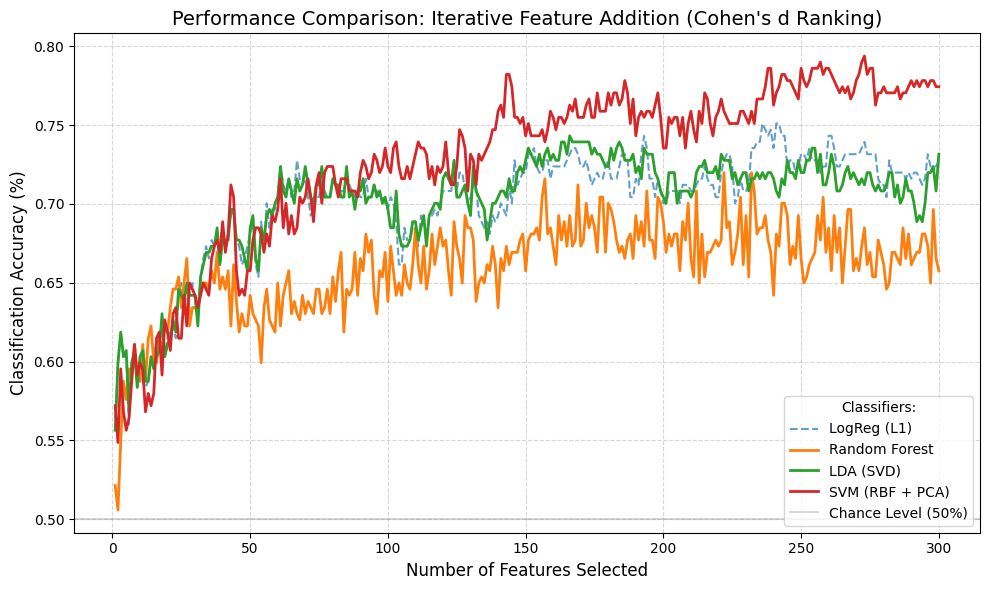

In [ ]:
# temp
import matplotlib.pyplot as plt

# Set plotting style for professional appearance
plt.figure(figsize=(10, 6))

# Plotting each model from the 'results' dictionary
plt.plot(results["count"], results["lr"], label="LogReg (L1)", linestyle='--', alpha=0.7)
plt.plot(results["count"], results["rf"], label="Random Forest", linewidth=2)
plt.plot(results["count"], results["lda"], label="LDA (SVD)", linewidth=2)
plt.plot(results["count"], results["svm"], label="SVM (RBF + PCA)", linewidth=2)
#plt.plot(results["count"], results["lda_csp"], label="LDA with CSP", linestyle=':', color='black')

# Aesthetics
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.title("Performance Comparison: Iterative Feature Addition (Cohen's d Ranking)", fontsize=14)
plt.xlabel("Number of Features Selected", fontsize=12)
plt.ylabel("Classification Accuracy (%)", fontsize=12)

# Reference line for chance level
plt.axhline(y=0.5, color='gray', linestyle='-', alpha=0.3, label="Chance Level (50%)")

plt.legend(title="Classifiers:", loc="lower right", frameon=True)
plt.tight_layout()

# Show plot
plt.show()


#### Evaluation of best model

In [ ]:
import numpy as np

# Example: pick best among RF, LDA, SVM (exclude LDA+CSP because it's a different X input)
best_rf_idx = int(np.argmax(results["rf"]))
best_lda_idx = int(np.argmax(results["lda"]))
best_svm_idx = int(np.argmax(results["svm"]))
best_lr_idx = int(np.argmax(results["lr"]))


candidates = [
    ("rf", best_rf_idx, results["rf"][best_rf_idx]),
    ("lda", best_lda_idx, results["lda"][best_lda_idx]),
    ("svm", best_svm_idx, results["svm"][best_svm_idx]),
    ("lr", best_lr_idx, results["lr"][best_lr_idx]),
]

best_model_name, best_idx, best_score = max(candidates, key=lambda x: x[2])
best_k = results["count"][best_idx]

print("Best model:", best_model_name)
print("Best #features:", best_k)
print("Best held-out accuracy:", best_score)


Best model: svm
Best #features: 273
Best held-out accuracy: 0.7937743190661478


##### Confusion matrix function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_pretty_confusion_matrix( # chatGPT model 5.2 code
    y_true,
    y_pred,
    class_names=("No Movement", "Movement"),
    normalize=True,
    title="Confusion Matrix (SVM)"
):
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    else:
        cm_norm = cm

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, cmap="Blues")

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)

    # Annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize:
                text = f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)"
            else:
                text = f"{cm[i, j]}"
            ax.text(
                j, i, text,
                ha="center", va="center",
                fontsize=11,
                color="white" if cm_norm[i, j] > 0.5 else "black"
            )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proportion", rotation=-90, va="bottom")

    plt.tight_layout()
    plt.show()


##### spatial relevance of the selected features

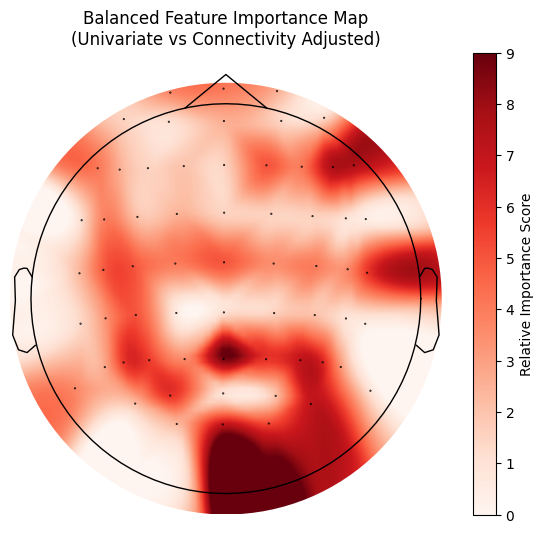

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


# 2. Balanced Weighting
electrode_weights = defaultdict(float)

for feat in top_cohen_feature_names[:273]:
    found_electrodes = [el for el in ELECTRODES if f"_{el}" in feat or feat.endswith(el)]

    if len(found_electrodes) == 1:
        # Univariate feature (PSD, Hjorth, κλπ) -> Total weight 1.0
        electrode_weights[found_electrodes[0]] += 1
    elif len(found_electrodes) == 2:
        # Connectivity feature (Correlation) -> Total feature weight 1.0, 0.5 each electrode
        electrode_weights[found_electrodes[0]] += 0.5
        electrode_weights[found_electrodes[1]] += 0.5

# 3. convert matrix for MNE
weights = np.array([electrode_weights[el] for el in ELECTRODES])

# 4. Topomap creation
info = mne.create_info(ch_names=ELECTRODES, sfreq=256, ch_types='eeg')
info.set_montage(mne.channels.make_standard_montage('standard_1020'))

fig, ax = plt.subplots(figsize=(8, 6))
im, _ = mne.viz.plot_topomap(weights, info, axes=ax, show=False, cmap='Reds', contours=0)

ax.set_title("Balanced Feature Importance Map\n(Univariate vs Connectivity Adjusted)", fontsize=12)
fig.colorbar(im, ax=ax, label='Relative Importance Score')
plt.show()

##### find best model hyperparams

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Prepare data with your 273 top features
top_273_features = top_features_ordered[:273]
X_train_273 = X_train_full[top_273_features].values
X_test_273 = X_test_full[top_273_features].values

# 2. Define the Pipeline
# We keep PCA inside the pipeline to avoid leakage during cross-validation
tuning_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("svm", SVC(random_state=42))
])

# 3. Define the Hyperparameter Grid
# C: Regularization strength
# gamma: Kernel coefficient (defines how far the influence of a single sample reaches)
# kernel: The type of decision boundary
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'svm__kernel': ['rbf', 'poly', 'sigmoid']
}

# 4. Initialize GridSearchCV
# cv=5: 5-fold cross-validation
# n_jobs=-1: Use all available CPU cores
grid_search = GridSearchCV(tuning_pipe, param_grid, cv=StratifiedKFold(5),
                           scoring='accuracy', n_jobs=-1, verbose=1)

# 5. Execute Tuning
grid_search.fit(X_train_273, y_train)

# 6. Results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# Evaluate on the unseen test set
best_model = grid_search.best_estimator_
test_acc = accuracy_score(y_test, best_model.predict(X_test_273))
print(f"Final Test Accuracy with Tuned SVM: {test_acc:.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'sigmoid'}
Best CV Accuracy: 0.7617
Final Test Accuracy with Tuned SVM: 0.7704


##### final Kfold performacne evaluation

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# best features dataset
selected_feature_names = top_cohen_feature_names[:best_k]
X_final = X_features_all[selected_feature_names].to_numpy(dtype=np.float32)

# best model defintion
svm_final = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("svm", SVC(
        kernel="sigmoid",
        C=0.1,
        gamma=0.01,
        probability=True,
        random_state=42
    ))
])


# train with kfold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


scoring = {
    "acc": "accuracy",
    "bal_acc": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_out = cross_validate(
    svm_final, X_final, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

for k, v in cv_out.items():
    if k.startswith("test_"):
        print(k, "mean=", np.mean(v), "std=", np.std(v))


test_acc mean= 0.769707563229572 std= 0.016800699725776885
test_bal_acc mean= 0.7697068798449612 std= 0.016800512203011077
test_f1 mean= 0.7699647937145194 std= 0.009436184394583219
test_roc_auc mean= 0.8462563211603683 std= 0.01486384869268943


##### confuison matrix

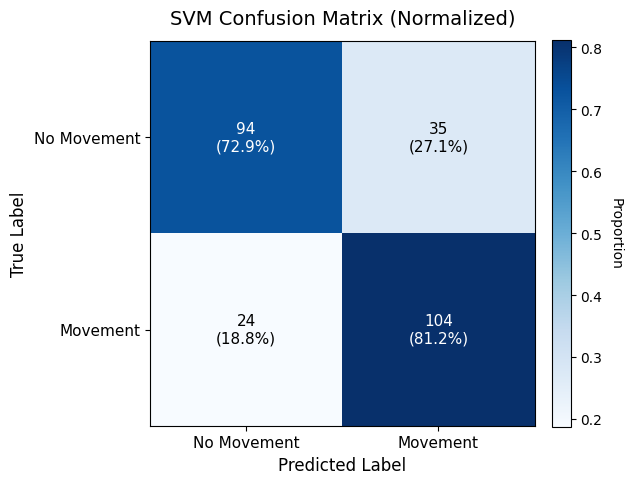

In [ ]:
#train for confusion matrix evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)
svm_final.fit(X_train, y_train)
y_pred = svm_final.predict(X_test)

#print(classification_report(y_test, y_pred, digits=4))

plot_pretty_confusion_matrix(
    y_test,
    y_pred,
    class_names=["No Movement", "Movement"],
    normalize=True,
    title="SVM Confusion Matrix (Normalized)"
)

##### used features for final best model

In [ ]:
print(f"\nTop {best_k} selected features used for SVM evaluation:\n")

for i, feat in enumerate(selected_feature_names[:273], 1):
    print(f"{i:02d}. {feat}")


Top 273 selected features used for SVM evaluation:

01. corr_F8_FC6
02. corr_F5_PO4
03. hjorth_mob_Pz
04. entropy_TP7
05. hjorth_comp_Pz
06. corr_C1_PO8
07. corr_P3_FC4
08. corr_AF3_AFz
09. corr_AFz_Fz
10. corr_Pz_Fpz
11. corr_P5_Fp2
12. psd_log_gamma_C5
13. corr_TP7_FT8
14. corr_Fp1_P4
15. corr_FC3_P5
16. corr_Fp1_FC5
17. corr_T7_P10
18. erp_latency_AF8
19. corr_FC2_C2
20. psd_log_theta_O2
21. corr_F2_CP6
22. corr_CP5_F6
23. corr_C3_TP7
24. var_AF8
25. corr_Oz_Fp2
26. corr_F1_C4
27. corr_F6_PO8
28. erp_peak_CP6
29. corr_AFz_P4
30. corr_Oz_CP6
31. psd_log_alpha_POz
32. corr_FC2_P8
33. corr_P1_AF4
34. corr_PO3_O2
35. kurt_FC1
36. corr_F6_P2
37. entropy_F6
38. psd_log_theta_Pz
39. corr_CP3_Fpz
40. corr_Fz_T8
41. corr_P5_O2
42. corr_C3_O1
43. corr_Fp2_F6
44. corr_F7_C3
45. psd_log_alpha_CP4
46. kurt_PO3
47. corr_C1_CP1
48. ratio_alpha_beta_FCz
49. psd_log_delta_F4
50. corr_F7_Fpz
51. psd_log_beta_CP5
52. corr_Fp1_CP4
53. entropy_P1
54. corr_FT7_C5
55. corr_C1_CP5
56. corr_PO8_PO4
57. hjo